<!-- <p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1aS4vX-ucDKBmZmZMrBwgjl_DvLAadX2C" width=900/></p> -->


<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

# Домашнее задание. RAG.

В этом домашнем задании вам предстоит создать туристический RAG, провести EDA и проявить креатив! :)

Вам дан набор данных, содержащий информацию о памятниках, архитектуре и других значимых местах. В данных есть:
* название достопримечательности;
* идентификатор на WikiData;
* город расположения;
* координаты долготы и широты;
* описание (извлеченное из WikiData);
* изображение в формате base64;
* сгенерированное описание изображения (генерация с помощью модели BLIP).

Некоторые из памятников могут встречаться несколько раз, но с различными изображениями, из которых не все могут быть качественными. Для компенсации этого даны текстовые описания.

Часть данных взята с Национальной технологической олимпиады студентов по CV. Базовое решение предполагает использование мультимодального ru-CLIP. Но в данном домашнем задании предлагается решить эту задачу творчески, используя NLP подход.

## Установка и импорт библиотек

In [1]:
!pip install -q gdown torch transformers==4.49 transformers accelerate bitsandbytes langchain sentence-transformers faiss-cpu openpyxl datasets langchain-community ragatouille umap-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [45]:
import gdown
import pandas as pd
from tqdm.notebook import tqdm
from typing import Optional, List, Tuple
import matplotlib.pyplot as plt
from langchain.docstore.document import Document as LangchainDocument
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer
from langchain.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy
import numpy as np
import plotly.express as px
from transformers import pipeline
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from ragatouille import RAGPretrainedModel

from sklearn.decomposition import PCA
import umap

import plotly.express as px



#------------------------------------------------------------------------------------
# from langchain.text_splitter import ... # выберите другую стратегию разбивки на чанки

# pd.set_option("display.max_colwidth", None)

## Загрузка данных (4 балла)

In [3]:
url = 'https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk'
output = 'file.csv'

gdown.download(url, output, quiet=False)

data = pd.read_csv('file.csv')

Downloading...
From (original): https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk
From (redirected): https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk&confirm=t&uuid=80f592b2-46ba-4087-a42c-7a9c5f198f06
To: /content/file.csv
100%|██████████| 672M/672M [00:11<00:00, 58.9MB/s]


In [4]:
data.head()

,Unnamed: 0,Name,WikiData,City,Lon,Lat,description,image,en_txt
0,0,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there are two people that are standing on a tr...
1,1,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed building with a blue and white exterior...
2,2,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
3,3,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
4,4,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a boat that is in the water near a bu...


Для декодирования изображений, закодированных в формате base64, можно использовать следующий код:

In [5]:
import base64
import requests
import matplotlib.pyplot as plt
from PIL import Image
import PIL
from io import BytesIO

In [6]:
def get_image(data):
  image = Image.open(BytesIO(base64.b64decode(data))).convert('RGB')
  return image

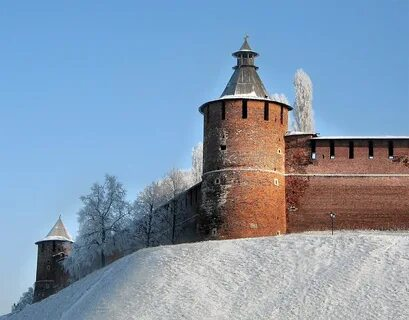

In [7]:
get_image(data.sample(1)['image'].tolist()[0])

В данных есть выбросы — записи, не относящихся к туристическим или историческим объектам. Для очистки данных можно, например, использовать алгоритм TF-IDF: создаем корпус текстов из описаний, применяем TF-IDF, извлекаем наиболее редко или часто встречающиеся слова. Они могут указывать на мусорные данные, такие как мемы, баннеры или личные фото людей. После выделения подозрительных паттернов, можно провести ручную проверку и фильтрацию данных.

Для дальнейшего тестирования и получения чистых сэмплов, рекомендуется взять не менее 100 чистых образцов со стратификацией по городу и названию места. Это можно сделать, выбрав случайным образом несколько образцов из каждой категории (город + название места), чтобы обеспечить равномерное представительство и разнообразие данных.

**!! Важно:** Помните, что чистые сэмплы одного и того же места выдадут примерно одинаковое описание. Есть несколько стратегий, как повысить разнообразие ответов:

- выбор одного самого лучшего:
  - самое длинное описание
  - смое подходящие по мнению LLM
- конкатенация описаний (но важно не сконкатенировать слишком много)

Изображения можно отдать в мета-данные.

In [8]:
#очистим data['description']
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')
russian_stop_words = stopwords.words('russian')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [9]:
data['description'] = data['description'].fillna('').str.lower().tolist()
vectorizer = TfidfVectorizer(stop_words=russian_stop_words)
tfidf_matrix = vectorizer.fit_transform(data['description'])

terms = vectorizer.get_feature_names_out()
tfidf_scores = tfidf_matrix.max(axis=0).toarray().ravel()

sorted_terms = pd.Series(tfidf_scores, index=terms).sort_values(ascending=False)

In [10]:
#самые популярные слова
sorted_terms.head()

,0
памятник,1.000000
музей,1.000000
библиотека,0.928676
предприятие,0.927447
гостиница,0.927447


In [11]:
top_terms = sorted_terms.head(20)
rare_terms = sorted_terms.tail(20)

In [12]:
data['top_terms'] = data['description'].apply(lambda x: any(term in x for term in top_terms.index))
data['rare_terms'] = data['description'].apply(lambda x: any(term in x for term in rare_terms.index))

In [13]:
#удалим строки с самыми популярными и самыми непопулярными словами
filtered_df = data[~(data['top_terms'] | data['rare_terms'])].copy()

In [14]:
#выберем несколько объектов из группы Город - Название
filtered_df['group'] = filtered_df['City'] + '___' + filtered_df['Name']
samples_per_group = 100 / filtered_df['group'].nunique()

stratified_sample = (
    filtered_df
    .groupby('group', group_keys=False)
    .apply(lambda g: g.sample(n=min(len(g), int(np.ceil(samples_per_group))), random_state=42))
    .reset_index(drop=True)
)
stratified_sample.head()

/tmp/ipython-input-14-4189245859.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(len(g), int(np.ceil(samples_per_group))), random_state=42))


,Unnamed: 0,Name,WikiData,City,Lon,Lat,description,image,en_txt,top_terms,rare_terms,group
0,2158,1941-1945,NaN,Владимир,40.362949,56.111187,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,a close up of a military tank with a medal on it,False,False,Владимир___1941-1945
1,3391,2000 летию Рождества Христова,NaN,Владимир,40.408882,56.127674,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed cross on a pedestal in a snowy church,False,False,Владимир___2000 летию Рождества Христова
2,1008,église arménienne de Vladimir,Q18331756,Владимир,40.456497,56.154667,армянская церковь в г. владимир россии,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,a view of a large white building with a clock ...,False,False,Владимир___église arménienne de Vladimir
3,84,Авиамеханический колледж,Q18786015,Владимир,40.387318,56.126278,владимирский авиамеханический колледж,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,students sitting at desks in a classroom with ...,False,False,Владимир___Авиамеханический колледж
4,3053,Аптекарь,NaN,Владимир,40.402309,56.127251,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a cabinet with many bottles and a lam...,False,False,Владимир___Аптекарь


In [15]:
#возьмем топ2 самых подробных(длинных) описаний для каждой группы
stratified_sample['desc_length'] = stratified_sample['description'].str.len()

diverse_selection = (
    stratified_sample
    .sort_values('desc_length', ascending=False)
    .groupby('group')
    .head(2)
)
diverse_selection.head()

,Unnamed: 0,Name,WikiData,City,Lon,Lat,description,image,en_txt,top_terms,rare_terms,group,desc_length
201,1503,Театр оперы и балета,Q172218,Нижний Новгород,44.017212,56.315525,нижегородский государственный академический те...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed view of a large auditorium with a stage...,False,False,Нижний Новгород___Театр оперы и балета,84
229,344,Больница имени Н. В. Соловьёва,Q4091101,Ярославль,39.863880,57.638920,гауз яо клиническая больница скорой медицинско...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,doctors and nurses in a hospital operating roo...,False,False,Ярославль___Больница имени Н. В. Соловьёва,76
155,798,Дмитриевская башня,Q18406802,Нижний Новгород,44.005676,56.327045,"проездная башня нижегородского кремля, один из...",/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed brick building with a green roof and a ...,False,False,Нижний Новгород___Дмитриевская башня,73
156,997,Дмитровская башня,Q18406802,Нижний Новгород,44.005646,56.327095,"проездная башня нижегородского кремля, один из...",/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a tall brick building with a green ro...,False,False,Нижний Новгород___Дмитровская башня,73
95,3245,Дом Маева,Q56210596,Екатеринбург,60.613888,56.843056,деревянный особняк начала xx века на вознесенс...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed woman in a fur coat posing for a picture,False,False,Екатеринбург___Дом Маева,71


In [16]:
stratified_sample = stratified_sample[['Name', 'City', 'description', 'en_txt', 'image']]
# итоговая база данных
stratified_sample.head()

,Name,City,description,en_txt,image
0,1941-1945,Владимир,,a close up of a military tank with a medal on it,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...
1,2000 летию Рождества Христова,Владимир,,arafed cross on a pedestal in a snowy church,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...
2,église arménienne de Vladimir,Владимир,армянская церковь в г. владимир россии,a view of a large white building with a clock ...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...
3,Авиамеханический колледж,Владимир,владимирский авиамеханический колледж,students sitting at desks in a classroom with ...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...
4,Аптекарь,Владимир,,there is a cabinet with many bottles and a lam...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...


Здесь предлагаем вам построить RAG с использованием моделей, которые не были представлены на семинаре (включая другие векторные базы данных). Можно воспользоваться материалами по этой ссылке: [data_connection/vectorstores](https://python.langchain.com/v0.1/docs/modules/data_connection/vectorstores/).

!Важно, не забудьте отранжировать чанки текстов с помощью `ragatouille`. На практике порядок текстов в промпте влияет на точность ответа.

In [17]:
from langchain.docstore.document import Document as LangchainDocument

RAW_KNOWLEDGE_BASE = [
    LangchainDocument(
        page_content=stratified_sample["Name"][i] + ': ' + stratified_sample["description"][i],
        metadata={"City": stratified_sample["City"][i]
                 })
    for i in tqdm(range(len(stratified_sample)))
]

  0%|          | 0/299 [00:00<?, ?it/s]

In [18]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

MARKDOWN_SEPARATORS = [
    "\n#{1,6} ",
    "```\n",
    "\n\\*\\*\\*+\n",
    "\n---+\n",
    "\n___+\n",
    "\n\n",
    "\n",
    " ",
    "",
]

CHUNK_SIZE = 100

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,  # Максимальное количество символов в чанке
    chunk_overlap=int(CHUNK_SIZE / 10),  # Количество символов, которые будут перекрываться между чанками
    add_start_index=True,  # Если "True", то включает начальный индекс чанка в метаданные
    strip_whitespace=True,  # Если значение "True", то пробелы удаляются из начала и конца каждого документа
    separators=MARKDOWN_SEPARATORS,
)

docs_processed = []
for doc in RAW_KNOWLEDGE_BASE:
    docs_processed += text_splitter.split_documents([doc])

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/823 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.29G [00:00<?, ?B/s]

config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

Model's maximum sequence length: 512


  0%|          | 0/312 [00:00<?, ?it/s]

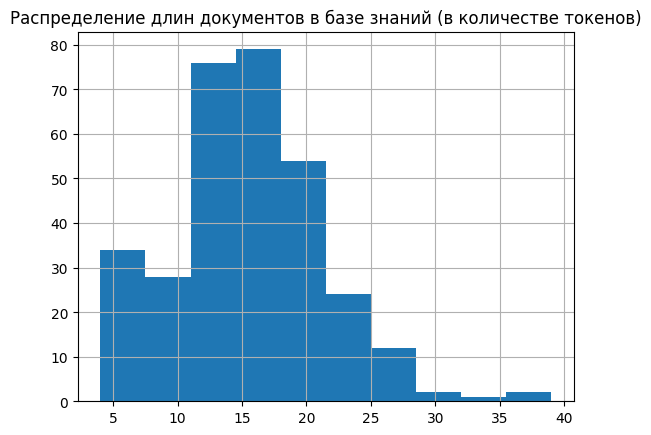

In [19]:
MODEL_NAME = "ai-forever/FRIDA"

TOKENIZER = AutoTokenizer.from_pretrained(MODEL_NAME,
#                                          max_length=1024
                                         )

# Чтобы получить значение max sequence_length, мы запросим базовый объект `SentenceTransformer`, используемый в RecursiveCharacterTextSplitter
print(f"Model's maximum sequence length: {SentenceTransformer(MODEL_NAME).max_seq_length}")
lengths = [len(TOKENIZER.encode(doc.page_content)) for doc in tqdm(docs_processed)]

# Построим график распределения длин документов, подсчитываемых как количество токенов
fig = pd.Series(lengths).hist()
plt.title("Распределение длин документов в базе знаний (в количестве токенов)")
plt.show()

In [20]:
embedding_model = HuggingFaceEmbeddings(
            model_name=MODEL_NAME,
            multi_process=True,
            model_kwargs={"device": "cuda"},
            encode_kwargs={"normalize_embeddings": True}, # `True` для косинусного сходства
        )

/tmp/ipython-input-20-4184416994.py:1: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(


In [21]:
pip install langchain_chroma

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 3.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.3/19.3 MB 105.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.2/284.2 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.6/101.6 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 110.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.8/65.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.7/55.7 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.5/118.5 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.2/196.2 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.9/104.9 kB 11.0 MB/s

In [22]:
from langchain_chroma import Chroma

KNOWNLEDGE_VECTOR_DATABASE = Chroma.from_documents(docs_processed, embedding_model)

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


In [50]:
user_query = "церкви в Нижнем Новгороде"
query_vector = embedding_model.embed_query(user_query)

In [51]:
print(f"\nStarting retrieval for {user_query=}...")
retrieved_docs = KNOWNLEDGE_VECTOR_DATABASE.similarity_search(query=user_query, k=10)

print("\n==================================Топ похожих документов==================================")
for i in tqdm(range(len(retrieved_docs))):
    print(i, ' - '.join([retrieved_docs[i].metadata['City'],
                         retrieved_docs[i].page_content]))
    print('='*50)


Starting retrieval for user_query='церкви в Нижнем Новгороде'...

==================================Топ похожих документов==================================


  0%|          | 0/10 [00:00<?, ?it/s]

0 Нижний Новгород - Рождественская церковь: церковь в нижнем новгороде
1 Нижний Новгород - Собор Александра Невского: православный собор в нижнем новгороде
2 Нижний Новгород - нижнего новгорода
3 Нижний Новгород - Церковь во имя Святого Пророка Божия Илии: церковь в нижнем новгороде
4 Нижний Новгород - Нижегородский Кремль: историческое здание в нижнем новгороде, россия
5 Нижний Новгород - Церковь Воскресения Христова: воскресенская церковь (нижний новгород)
6 Нижний Новгород - (нижний новгород)
7 Нижний Новгород - Храм Живоначальной Троицы: соборный храм в нижегородском районе нижнего новгорода
8 Нижний Новгород - Спасо-преображенский собор: православный храм в нижнем новгороде
9 Нижний Новгород - Благовещенский собор: монастырь в нижнем новгороде


Теперь добавим реранкер

In [25]:
from ragatouille import RAGPretrainedModel

RERANKER = RAGPretrainedModel.from_pretrained("colbert-ir/colbertv2.0")

artifact.metadata: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/405 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/colbert/utils/amp.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler()


In [52]:
relevant_docs = [doc.page_content for doc in retrieved_docs]
relevant_docs = RERANKER.rerank(user_query, relevant_docs, k=5)
relevant_docs

/usr/local/lib/python3.11/dist-packages/colbert/utils/amp.py:15: FutureWarning:

`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.

100%|██████████| 1/1 [00:00<00:00, 38.90it/s]


[{'content': 'Церковь во имя Святого Пророка Божия Илии: церковь в нижнем новгороде',
  'score': 28.84375,
  'rank': 0,
  'result_index': 3},
 {'content': 'Рождественская церковь: церковь в нижнем новгороде',
  'score': 28.390625,
  'rank': 1,
  'result_index': 0},
 {'content': 'Церковь Воскресения Христова: воскресенская церковь (нижний новгород)',
  'score': 27.234375,
  'rank': 2,
  'result_index': 5},
 {'content': 'Благовещенский собор: монастырь в нижнем новгороде',
  'score': 23.984375,
  'rank': 3,
  'result_index': 9},
 {'content': 'Собор Александра Невского: православный собор в нижнем новгороде',
  'score': 23.796875,
  'rank': 4,
  'result_index': 1}]

In [29]:
from transformers import pipeline
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

READER_MODEL_NAME = "HuggingFaceH4/zephyr-7b-beta"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)
model = AutoModelForCausalLM.from_pretrained(READER_MODEL_NAME, quantization_config=bnb_config)
tokenizer = AutoTokenizer.from_pretrained(READER_MODEL_NAME)

READER_LLM = pipeline(
    model=model,
    tokenizer=tokenizer,
    task="text-generation",
    do_sample=True,
    temperature=0.2,
    repetition_penalty=1.1,
    return_full_text=False,
    max_new_tokens=500,
)

config.json:   0%|          | 0.00/638 [00:00<?, ?B/s]

`low_cpu_mem_usage` was None, now default to True since model is quantized.


model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00008.safetensors:   0%|          | 0.00/1.89G [00:00<?, ?B/s]

model-00002-of-00008.safetensors:   0%|          | 0.00/1.95G [00:00<?, ?B/s]

...

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

Device set to use cuda:0


Формирование промта

In [53]:
prompt_in_chat_format = [
    {
        "role": "system",
        "content": """Ты чат бот ГИД, который помогает ориентироваться в городе,
а также рассказывает о местах и достопримечательностях в нем.
Используя информацию, содержащуюся в контексте, напиши краткий ответ на заданный вопрос.
Если ответ невозможно вывести из контекста скажи, что не знаешь.""",
    },
    {
        "role": "user",
        "content": """Контекст: {context} \n---
А теперь вопрос, на который вам нужно ответить.
Вопрос: {question}""",
    },
]


RAG_PROMPT_TEMPLATE = tokenizer.apply_chat_template(
    prompt_in_chat_format, tokenize=False, add_generation_prompt=True
)

In [54]:
relevant_docs_text = [doc['content'] for doc in relevant_docs]
context = "\nИзвлеченные документы:\n"
context += "".join([f"Документ {str(i)}:::\n" + doc for i, doc in enumerate(relevant_docs_text)])

final_prompt = RAG_PROMPT_TEMPLATE.format(question=user_query, context=context)

answer = READER_LLM(final_prompt)[0]["generated_text"]
print(answer)

В контексте предоставленных документов, известно об нескольких церквах в Нижнем Новгороде, включая Церковь во имя Святого Пророка Божия Илии, Рождественскую церковь, Церковь Воскресения Христова (также известная как Воскресенская церковь), Благовещенский собор (монастырь) и Собор Александра Невского (православный собор).


In [41]:
from transformers import Pipeline


def answer_with_rag(
    question: str,
    rag_prompt: str,
    llm: Pipeline,
    knowledge_index,
    reranker: Optional[RAGPretrainedModel] = None,
    num_retrieved_docs: int = 30,
    num_docs_final: int = 5,
    printing: bool=True
) -> Tuple[str, List[LangchainDocument]]:
    # Соберём документы с помощью ретривера
    if printing:
        print("=> Получение документов...")
    retrieved_docs = knowledge_index.similarity_search(query=question, k=num_retrieved_docs)
    relevant_docs = [doc.page_content for doc in retrieved_docs]

    if reranker:
        if printing:
            print("=> Ранжирование документов...")
        relevant_docs = reranker.rerank(question, relevant_docs, k=num_docs_final)
        relevant_docs = [doc["content"] for doc in relevant_docs]

    relevant_docs = relevant_docs[:num_docs_final]

    # Финальный промпт
    context = "\nИзвлеченные документы:"
    context += " ".join([f"\nДокумент {str(i)}: " + doc for i, doc in enumerate(relevant_docs)])

    final_prompt = rag_prompt.format(question=question, context=context)
    if printing:
        print(f'Промт для RAG: \n\n{final_prompt}')
        print("=> Генерация ответа...")
    answer = llm(final_prompt)[0]["generated_text"]

    return answer, relevant_docs

In [55]:
%%time

question = "посоветуй места в Нижнем Новгороде"

answer, relevant_docs = answer_with_rag(question, RAG_PROMPT_TEMPLATE, READER_LLM, KNOWNLEDGE_VECTOR_DATABASE, RERANKER)

print("==================================Ответ==================================\n")
print(f"{answer}")

=> Получение документов...
=> Ранжирование документов...


100%|██████████| 1/1 [00:00<00:00, 22.86it/s]

Промт для RAG: 

<|system|>
Ты чат бот ГИД, который помогает ориентироваться в городе,
а также рассказывает о местах и достопримечательностях в нем.
Используя информацию, содержащуюся в контексте, напиши краткий ответ на заданный вопрос.
Если ответ невозможно вывести из контекста скажи, что не знаешь.</s>
<|user|>
Контекст: 
Извлеченные документы:
Документ 0: Печёрский Вознесенский монастырь: монастырь в нижнем новгороде 
Документ 1: Собор Александра Невского: православный собор в нижнем новгороде 
Документ 2: Спасо-преображенский собор: православный храм в нижнем новгороде 
Документ 3: Дом Советов: административное здание в нижнем новгороде, россия 
Документ 4: Парк имени А.С. Пушкина: парк культуры и отдыха в нижнем новгороде. 
---
А теперь вопрос, на который вам нужно ответить.
Вопрос: посоветуй места в Нижнем Новгороде</s>
<|assistant|>

=> Генерация ответа...


==================================Ответ==================================

Чтобы посетить достопримечательности в Нижнем Новгороде, я рекомендую начать с Печёрского Вознесенского монастыря, который расположен в историческом центре города. Затем продолжай путь к Собору Александра Невского, который является одним из самых известных православных соборов в Нижнем Новгороде. После этого, вы можете посетить Спасо-преображенский собор, который также находится в нижней части города. Если вы ещё время осталось, то я также рекомендую посетить Дом Советов, который служил как административное здание, так и место для проведения культурных мероприятий. В конце дня, вы можете найти себе спокойную атмосферу в Парке имени А.С. Пушкина, который предоставит вам возможность отдохнуть и проложить свой путь обратно домой.
CPU times: user 24.5 s, sys: 518 ms, total: 25 s
Wall time: 35.3 s


Выполните визуализацию эмбеддингов при помощи метода главных компонент (PCA) и Uniform Manifold Approximation and Projection (UMAP).

In [56]:
pca_emb = PCA(n_components=2)

documents_projected = pca_emb.fit_transform(KNOWNLEDGE_VECTOR_DATABASE.get(include=["embeddings"])['embeddings'])

In [58]:
df = pd.DataFrame.from_dict(
    [
        {
            "x": documents_projected[i, 0],
            "y": documents_projected[i, 1],
            "source": docs_processed[i].metadata["City"],
            "extract": docs_processed[i].page_content[:100] + "...",
            "symbol": "circle",
            "size_col": 4,
        }
        for i in range(len(docs_processed))
    ]
    + [
        {
            "x": documents_projected[-1, 0],
            "y": documents_projected[-1, 1],
            "size_col": 100,
            "symbol": "star",
        }
    ]
)

# Визуализируем эмбеддинги
fig = px.scatter(
    df,
    x="x",
    y="y",
    color="source",
    hover_data="extract",
    size="size_col",
    symbol="symbol",
    color_discrete_map={"User query": "black"},
    width=1000,
    height=700,
)
fig.update_traces(
    marker=dict(opacity=1, line=dict(width=0, color="DarkSlateGrey")),
    selector=dict(mode="markers"),
)
fig.update_layout(
    legend_title_text="<b>Источник чанка</b>",
    title="<b>2D-проекция вложений чанка с помощью PaCMAP</b>",
)
fig.show()

# RAGAS

RAGAS - это система, созданная для автоматической оценки эффективности модели RAG. Она представляет собой комплексный инструмент, способный оценить как качество извлечения информации, так и качество созданного текста. Это достигается благодаря использованию различных метрик, которые анализируют разные аспекты ответов, сгенерированных языковой моделью.



## Метрики оценки в RAGAS

### Faithfulness
Оценивает, насколько ответы языковой модели верно передают информацию, содержащуюся в источниках данных. Это критически важно, чтобы гарантировать, что модель не искажает или не меняет информацию при её интерпретации.

---

$
Faithfulness = \frac{\text{|Number of claims that can be inferred from given context|}}{\text{|Total number of claims in the generated answer|}}
$

### Answer Relevancy
Демонстрирует, насколько ответы соответствуют заданным вопросам. Это важный аспект, так как даже правильный ответ с технической точки зрения может быть ненужным, если он не отвечает на конкретный вопрос пользователя.

---

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} cos(E_{g_i}, E_o)$

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} \frac{E_{g_i} \cdot E_o}{\|E_{g_i}\|\|E_o\|}$

Где:

* $E_{g_i}$ - это эмбеддинг сгенерированного ответа $i$

* $E_o$ - это эмбеддинг исходного вопроса.

* $N$ - это количество сгенерированных вопросов, которое по умолчанию равно 3.

### Context Recall и Context Precision
Эти метрики измеряют эффективность модели в учете контекста вопроса для формирования ответа. "Context Recall" оценивает количество использованной информации из контекста в ответе, в то время как "Context Precision" оценивает точность и релевантность использования контекстной информации.

---

* $ \text{context recall} = \frac{\text{|GT sentences that can be attributed to context|}}{\text{|Number of sentences in GT|}} $
* $Context Precision@k = \frac{\sum \text{precision@k}}{\text{total number of relevant items in the top K results}}$
  * $Precision@k = \frac{\text {true positives@k}}{\text{(true positives@k + false positives@k)}}$

### Answer Semantic Similarity
Оценивает степень семантической близости между ответом модели и эталонным ответом. Это позволяет определить, насколько естественно и точно модель способна воссоздавать человеческий язык.

### Answer Correctness
Оценка корректности ответа. Это последний шаг в проверке, чтобы убедиться, предоставляет ли модель точную и достоверную информацию в своем ответе.

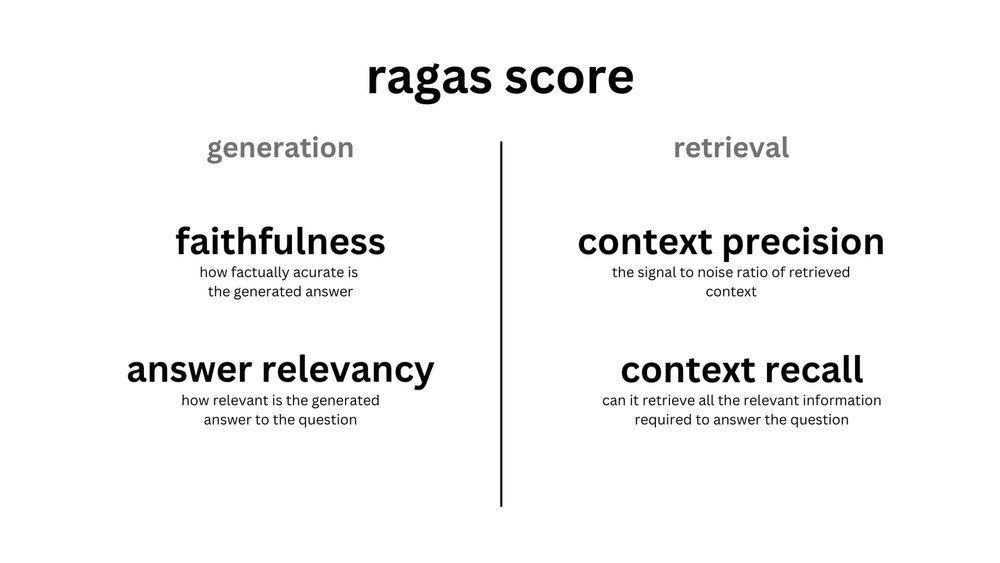

В этом задании вам нужно реализовать метрику answer_relevancy в коде. Опционально за допбаллы можно реализовать другие метрики.

Для этого датасет нужно привести к виду, в котором будут следующие поля:

### 1. question
- Смысл: Эта колонка содержит вопросы, на которые нужно найти ответы. В контексте задач QA, это основная информация, которую модель должна обработать для генерации ответа.
- Пример: "Каковы преимущества RAG?"

### 2. ground_truths
- Смысл: В этой колонке находятся правильные ответы на соответствующие вопросы. Это может использоваться для оценки производительности модели, так как позволяет сравнить сгенерированные ответы с эталонными.
- Пример: "RAG улучшает качество генерации, используя внешние источники информации."

### 3. answer
- Смысл: Эта колонка содержит ответы, которые генерирует модель на основе заданных вопросов. Это может быть результат работы модели, которую вы тестируете или обучаете.
- Пример: "RAG позволяет моделям извлекать информацию из внешних источников, что улучшает их способность отвечать на сложные вопросы."

### 4. contexts
- Смысл: Эта колонка предоставляет контекст или дополнительную информацию, которая может быть полезна для понимания вопроса или для формирования ответа. Это может быть текст, из которого был извлечен ответ, или другие релевантные документы.
- Пример: "RAG (Retrieval-Augmented Generation) — это метод, который использует внешние базы данных для получения информации при генерации текста."

HINT: Поле question можно тоже сгенерировать. Например, можно попросить модель задать вопрос по описанию изображения.

HINT: Для answer_relevancy нужны не все поля

HINT: Инференс такого эксперимента может быть долгим. План минимум: возьмите 100 случайных сэмплов.